# 심화 미션: 스마트팜 온실 출하 기록
- 상황: 선별대에서 도장을 찍기 전에 등외를 미리 알고 싶다
- 목표: 오늘 배운 순서를 다른 데이터로 혼자 한 바퀴 돌린다

### 용어 풀이 - 온실에서 쓰는 말

| 말 | 뜻 |
|---|---|
| 상품 / 등외 | 선별대에서 붙이는 판정. 등외는 제값에 못 파는 것 |
| 양액 (EC) | 물에 녹인 거름. 그 진하기를 dS/m 라는 단위로 잰다 |
| 산도 (pH) | 산성인지 알칼리성인지. 7이 중간이고 낮을수록 산성 |
| 토양 수분 | 흙에 물기가 얼마나 있는지 (%) |
| 야간 최저 기온 | 밤에 가장 낮았던 기온. 작물이 스트레스를 받는 지점 |

## Q1. 파일 열고 크기 확인하기

In [1]:
import pandas as pd

df = pd.read_csv('../../data/day03_greenhouse.csv')

print('행 수:', df.shape[0])
print('열 수:', df.shape[1])

행 수: 2000
열 수: 13


## Q2. 등외는 얼마나 드문가

In [2]:
건수 = df['result'].value_counts()
전체건수 = len(df)
등외비율 = 건수['등외'] / 전체건수 * 100

print('상품:', 건수['상품'], '건')
print('등외:', 건수['등외'], '건')
print('전체:', 전체건수, '건')
print('등외 비율:', round(등외비율, 2), '%')

상품: 1861 건
등외: 139 건
전체: 2000 건
등외 비율: 6.95 %


## Q3. 정답표를 숫자로 바꾸기

In [3]:
# result 열(상품/등외)을 숫자로 바꾼 등외여부 열 추가 (등외=1, 상품=0)
df['등외여부'] = (df['result'] == '등외').astype(int)

print(df[['result', '등외여부']].head())
print()
print(df['등외여부'].value_counts())

  result  등외여부
0     상품     0
1     상품     0
2     상품     0
3     상품     0
4     상품     0

등외여부
0    1861
1     139
Name: count, dtype: int64


## Q4. 입력과 정답으로 가르기

### 용어 풀이

| 말 | 뜻 |
|---|---|
| 입력(X) | 모델이 보고 판단에 쓰는 값들. 여기서는 숫자로 된 센서·환경 측정값 |
| 정답(y) | 모델이 맞혀야 하는 값. 여기서는 등외여부(등외=1, 상품=0) |

In [4]:
# 숫자로 된 센서·환경 측정값만 입력(X)으로 쓴다
# (batch_id/harvested_at/house_id/crop은 식별자·문자 값이라 제외, result·등외여부는 정답이라 제외)
입력_열 = ['temp_avg', 'humidity_avg', 'co2_ppm', 'soil_moisture', 'ec', 'ph', 'light_hours', 'night_temp_min']

X = df[입력_열]
y = df['등외여부']

print('X:', X.shape)
print('y:', y.shape)
print('입력 열:', 입력_열)

X: (2000, 8)
y: (2000,)
입력 열: ['temp_avg', 'humidity_avg', 'co2_ppm', 'soil_moisture', 'ec', 'ph', 'light_hours', 'night_temp_min']


[Q4 결과]<br>
입력(X) : 센서·환경 측정값 [8]개 열, [2000]행<br>
정답(y) : 등외여부 열, [2000]행<br>
→ X는 모델이 보는 값, y는 X를 보고 맞혀야 하는 등외 여부

## Q5. 학습용과 시험용으로 나누기

### 용어 풀이

| 말 | 뜻 |
|---|---|
| 학습용(train) | 모델이 규칙을 배우는 데 쓰는 데이터 |
| 시험용(test) | 학습에는 쓰지 않고, 마지막에 실력을 확인할 때만 쓰는 데이터 |
| random_state | 무작위로 섞을 때 쓰는 시작값. 같은 값을 주면 몇 번을 다시 돌려도 항상 똑같이 나뉜다 |
| stratify | 나눌 때 정답(y)의 비율을 원본과 같게 맞춰주는 옵션 |

In [5]:
from sklearn.model_selection import train_test_split

# random_state를 고정해서 다시 실행해도 같은 결과가 나오게 하고,
# stratify=y로 학습용/시험용의 등외 비율을 원본과 비슷하게 맞춘다
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('학습용:', X_train.shape[0], '행, 등외', y_train.sum(), '건, 비율', round(y_train.mean() * 100, 2), '%')
print('시험용:', X_test.shape[0], '행, 등외', y_test.sum(), '건, 비율', round(y_test.mean() * 100, 2), '%')
print('원본  :', X.shape[0], '행, 등외', y.sum(), '건, 비율', round(y.mean() * 100, 2), '%')

학습용: 1600 행, 등외 111 건, 비율 6.94 %
시험용: 400 행, 등외 28 건, 비율 7.0 %
원본  : 2000 행, 등외 139 건, 비율 6.95 %


[Q5 결과]<br>
학습용 : [1600]행, 등외 [111]건, 비율 [6.94]%<br>
시험용 : [400]행, 등외 [28]건, 비율 [7.0]%<br>
원본   : [2000]행, 등외 [139]건, 비율 [6.95]%<br>
→ random_state=42로 고정해 재실행해도 같은 결과, stratify=y로 학습용·시험용의 등외 비율이 원본과 비슷하게 유지됨

## Q6. 아무것도 배우지 않은 기준 모델

### 용어 풀이

| 말 | 뜻 |
|---|---|
| 기준 모델 | 학습을 전혀 하지 않고 늘 같은 답만 내놓는 모델. 비교의 바닥선이 된다 |
| 정확도 | 시험용 중에서 맞힌 비율 |

In [6]:
import numpy as np

# 학습은 하지 않고, 시험용 전부를 상품(0)이라고만 답한다
기준예측 = np.zeros(len(y_test), dtype=int)
기준정확도 = (기준예측 == y_test).mean()

print('시험용 상품:', (y_test == 0).sum(), '건')
print('시험용 등외:', (y_test == 1).sum(), '건')
print('기준 모델(전부 상품) 정확도:', round(기준정확도 * 100, 2), '%')

시험용 상품: 372 건
시험용 등외: 28 건
기준 모델(전부 상품) 정확도: 93.0 %


[Q6 결과]<br>
시험용 상품 : [372]건, 시험용 등외 : [28]건<br>
기준 모델(전부 상품) 정확도 : [93.0]%<br>
→ 등외가 드물어서, 아무것도 배우지 않고 늘 상품이라고만 답해도 정확도가 높게 나온다

## Q7. 데이터 상황을 보고 모델 추천받기

[데이터 상황]<br>
전체 [2,000]건 · 입력(숫자) 열 [8]개 · 등외 비율 약 [7]%<br>
→ 건수도 적고 열도 적은데, 맞혀야 할 등외는 드물게 섞여 있다

[추천받은 모델]<br>
1. [로지스틱 회귀] - [숫자 열 8개뿐이라 계수 하나하나가 무슨 뜻인지(어느 환경값이 등외를 늘리는지) 바로 읽힌다. 2,000건밖에 안 되는 작은 데이터에서는 파라미터가 적은 이 모델이 트리 계열보다 덜 흔들린다]<br>
2. [의사결정나무] - [자르는 기준이 "야간 최저 기온이 몇 도 밑이면" 식으로 눈에 보여서, 숫자에 약해도 결과를 설명하기 쉽다]<br>
내가 고른 것 : [로지스틱 회귀]<br>
→ 등외가 7%로 드물어서 어느 모델을 쓰든 정확도만으로는 안 속아야 하지만, 그중에서도 로지스틱 회귀는 확률을 내놓기 때문에 나중에 기준(0.5)을 낮춰 등외를 더 잡아내는 식의 조정이 쉽다는 점이 이 작은 데이터에서 특히 유리하다

In [7]:
# 오늘은 손보지 않은 기본 설정 그대로 — class_weight 등 불균형 보정 없음
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

모델들 = {
    '로지스틱 회귀': LogisticRegression(),
    '의사결정나무': DecisionTreeClassifier(random_state=42),
}

결과 = []
for 이름, model in 모델들.items():
    model.fit(X_train, y_train)
    예측 = model.predict(X_test)
    정확도 = (예측 == y_test).mean()
    결과.append({
        '모델': 이름,
        '등외라고 예측한 건수': int((예측 == 1).sum()),
        '정확도(%)': round(정확도 * 100, 2),
    })

비교표 = pd.DataFrame(결과).set_index('모델')
print('기준 모델(전부 상품) 정확도: 93.0 %')
비교표

기준 모델(전부 상품) 정확도: 93.0 %


C:\Users\13sx0\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,등외라고 예측한 건수,정확도(%)
모델,,
로지스틱 회귀,21,95.25
의사결정나무,23,95.25


[Q7 결과]<br>
기준 모델(전부 상품) : [93.0]%<br>
로지스틱 회귀 : 정확도 [95.25]%, 등외라고 예측한 건수 [21]건<br>
의사결정나무 : 정확도 [95.25]%, 등외라고 예측한 건수 [23]건<br>
→ 기준 모델보다 [두 모델 다 정확도가 높아졌고(93.0% → 95.25%), 무엇보다 기준 모델은 등외를 한 건도 못 잡았는데 두 모델은 각각 21건·23건을 등외라고 잡아냈다는 점이 실제로 배운 효과]

## Q8. 로지스틱 회귀 계수로 보기

### 용어 풀이

| 말 | 뜻 |
|---|---|
| 계수(coefficient) | 그 열의 값이 커질 때, 등외 쪽으로 얼마나 기우는지를 나타내는 숫자. 양수면 값이 클수록 등외 쪽, 음수면 값이 클수록 상품 쪽 |

In [8]:
# Q7에서 쓴 로지스틱 회귀를 다시 학습시켜 계수만 따로 뽑아본다
# (열마다 단위가 달라 계수 크기를 그대로 비교하긴 어렵지만, 부호(+/-)는 방향을 보여준다)
로지스틱 = LogisticRegression()
로지스틱.fit(X_train, y_train)

계수표 = pd.DataFrame({
    '입력 열': 입력_열,
    '계수': 로지스틱.coef_[0],
}).sort_values('계수', key=abs, ascending=False)

계수표

C:\Users\13sx0\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,입력 열,계수
7,night_temp_min,-1.220644
1,humidity_avg,0.290763
5,ph,-0.082215
0,temp_avg,-0.070535
3,soil_moisture,0.036900
2,co2_ppm,-0.015149
4,ec,0.007957
6,light_hours,0.005892


[Q8 결과]<br>
계수 절댓값이 가장 큰 열 : [night_temp_min] (계수 [-1.22])<br>
그다음 : [humidity_avg] (계수 [0.29])<br>
→ [night_temp_min이 음수로 가장 크다는 건, 야간 최저 기온이 낮을수록 등외가 될 가능성이 커진다는 뜻. humidity_avg는 양수라 습도가 높을수록 등외 쪽으로 기운다. 나머지 열(ph, temp_avg, soil_moisture, co2_ppm, ec, light_hours)은 계수가 0에 가까워 등외 판정에 미치는 영향이 상대적으로 작다]

## Q9. 학습시키고 시험용으로 예측하기

### 용어 풀이

| 말 | 뜻 |
|---|---|
| 표준화(StandardScaler) | 열마다 단위·범위가 다른 것을 평균 0, 분산 1로 맞춰주는 작업. 로지스틱 회귀처럼 거리·크기에 민감한 모델에서 특히 중요 |
| fit_transform / transform | 학습용에서만 기준(평균·분산)을 잡고(`fit_transform`), 시험용은 그 기준으로 변환만 한다(`transform`) — 시험용 정보가 학습에 새어 들어가지 않게 하기 위함 |

In [9]:
# 로지스틱 회귀는 스케일에 민감한 모델이라 표준화를 함께 넣는다
# (기준은 X_train으로만 잡고, X_test는 그 기준으로 변환만 한다)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_표준화 = scaler.fit_transform(X_train)
X_test_표준화 = scaler.transform(X_test)

# Q4~Q5에서 만든 학습용으로 학습시키고, 시험용에 대해 예측한다
model = LogisticRegression()
model.fit(X_train_표준화, y_train)

예측 = model.predict(X_test_표준화)

정확도 = (예측 == y_test).mean()
등외_예측_건수 = int((예측 == 1).sum())
그중_실제_등외 = int(((예측 == 1) & (y_test == 1)).sum())

print('1. 정확도:', round(정확도 * 100, 2), '%')
print('2. 등외라고 예측한 건수:', 등외_예측_건수)
print('3. 그중 실제로 등외였던 건수:', 그중_실제_등외)

1. 정확도: 94.5 %
2. 등외라고 예측한 건수: 20
3. 그중 실제로 등외였던 건수: 13


[Q9 결과]<br>
정확도 : [94.5]%<br>
등외라고 예측한 건수 : [20]건<br>
그중 실제로 등외였던 건수 : [13]건<br>
→ [표준화를 넣으니 정확도는 Q7의 95.25%보다 살짝 낮아졌지만(94.5%), 등외 20건 중 13건이 실제 등외였다 — 기준 모델(Q6)은 등외를 하나도 못 맞혔던 것과 비교하면, 학습을 통해 등외를 실제로 걸러내는 능력이 생겼다는 뜻]

## Q8. 혼동행렬 네 칸 채우기ㅋ

In [10]:
from sklearn.metrics import confusion_matrix

# Q7에서 고른 로지스틱 회귀(Q8에서 다시 학습시킨 것과 같은 표준화 없는 버전)의 예측을 그대로 쓴다
로지스틱_예측 = 로지스틱.predict(X_test)

행렬 = confusion_matrix(y_test, 로지스틱_예측)

상품인데_상품 = int(행렬[0, 0])
상품인데_등외 = int(행렬[0, 1])  # 헛경보
등외인데_상품 = int(행렬[1, 0])  # 놓친 등외
등외인데_등외 = int(행렬[1, 1])

print('상품인데 상품이라 한 것       :', 상품인데_상품, '건')
print('상품인데 등외라 한 것(헛경보)  :', 상품인데_등외, '건')
print('등외인데 상품이라 한 것(놓친 등외) :', 등외인데_상품, '건')
print('등외인데 등외라 한 것       :', 등외인데_등외, '건')

상품인데 상품이라 한 것       : 366 건
상품인데 등외라 한 것(헛경보)  : 6 건
등외인데 상품이라 한 것(놓친 등외) : 13 건
등외인데 등외라 한 것       : 15 건


[Q8 결과]<br>
상품인데 상품이라 한 것 : [366]건<br>
상품인데 등외라 한 것(헛경보) : [6]건<br>
등외인데 상품이라 한 것(놓친 등외) : [13]건<br>
등외인데 등외라 한 것 : [15]건<br>
→ [시험용 등외 28건 중 15건만 잡아내고 13건은 놓쳤다 — 정확도(95.25%)만 보면 좋아 보이지만, 실제로

헛경보6건보다 등외인데 상품이라고 한것 13건이 가장아플거 같다. 고객들은 좋은 상품이라고 생각해서 받았는데 상태가 불량이라 그 상품을 차후 안 사먹기 때문이다. 

## Q10. 재현율·정밀도·F1 구하고 기준 모델과 비교하기

### 용어 풀이

| 말 | 뜻 |
|---|---|
| 재현율 (recall) | 실제 등외 중 몇 %를 잡았나. 분모는 "실제 등외 전체"(등외인데 등외 + 등외인데 상품) |
| 정밀도 (precision) | 등외라고 한 것 중 진짜가 몇 %였나. 분모는 "등외라고 한 것 전체"(등외인데 등외 + 상품인데 등외) |
| F1 | 재현율과 정밀도를 함께 보는 값. 한쪽만 높으면 오르지 않는다 |

In [11]:
from sklearn.metrics import recall_score, precision_score, f1_score


def 평가(이름, 예측값):
    return {
        '모델': 이름,
        '재현율(%)': round(recall_score(y_test, 예측값, zero_division=0) * 100, 1),
        '정밀도(%)': round(precision_score(y_test, 예측값, zero_division=0) * 100, 1),
        'F1(%)': round(f1_score(y_test, 예측값, zero_division=0) * 100, 1),
    }


# 기준예측은 Q6에서 만든 것(전부 상품), 로지스틱_예측은 Q8에서 만든 것을 그대로 쓴다
비교표2 = pd.DataFrame([
    평가('기준 모델 (전부 상품)', 기준예측),
    평가('로지스틱 회귀', 로지스틱_예측),
]).set_index('모델')

비교표2

,재현율(%),정밀도(%),F1(%)
모델,,,
기준 모델 (전부 상품),0.0,0.0,0.0
로지스틱 회귀,53.6,71.4,61.2


[Q10 결과]<br>
기준 모델(전부 상품) : 재현율 [0.0]%, 정밀도 [0.0]%, F1 [0.0]%<br>
로지스틱 회귀 : 재현율 [53.6]%, 정밀도 [71.4]%, F1 [61.2]%<br>
→ [정확도만 보면 기준 모델(93.0%)과 로지스틱 회귀(95.25%)의 차이가 크지 않아 보이지만, 재현율·정밀도·F1은 0%에서 각각 53.6%·71.4%·61.2%로 완전히 다른 그림을 보여준다 — 기준 모델은 등외를 하나도 못 잡는 무용지물이고, 로지스틱 회귀는 실제 등외의 절반 이상을 잡아내는 실질적인 모델이다]

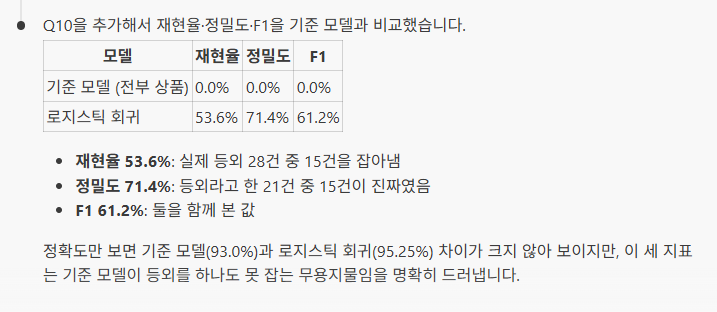

## Q9. 세 가지 지표 구하기

| | 정확도 | 재현율 | 정밀도 | F1 |
|---|---|---|---|---|
| 기준 모델 (전부 상품) |93.0% |0.0% |0.0% |0.0% |
| 로지스틱 회귀 |95.25% |53.6% |71.4% |61.2% |

## Q11. classification_report로 한 번에 보기

### 용어 풀이

| 말 | 뜻 |
|---|---|
| classification_report | precision·recall·f1-score를 클래스별로 한 번에 계산해 표로 보여주는 함수 |
| support | 그 클래스의 실제 개수(시험용 기준) |

In [12]:
from sklearn.metrics import classification_report

# 예측은 Q9에서 마지막으로 만든 것(표준화 넣은 로지스틱 회귀, 문턱 0.5)을 그대로 쓴다
print(classification_report(y_test, 예측, target_names=["상품", "등외"], digits=3))

              precision    recall  f1-score   support

          상품      0.961     0.981     0.971       372
          등외      0.650     0.464     0.542        28

    accuracy                          0.945       400
   macro avg      0.805     0.723     0.756       400
weighted avg      0.939     0.945     0.941       400



[Q11 결과] (로지스틱 회귀 기준 — 표준화 적용, 문턱 0.5)

| | precision | recall | f1-score | support |
|---|---|---|---|---|
| 상품 | [0.961] | [0.981] | [0.971] | [372] |
| 등외 | [0.650] | [0.464] | [0.542] | [28] |
| accuracy | | | [0.945] | [400] |

→ 등외 쪽 recall(0.464)과 precision(0.650)은 Q10에서 손으로 구한 53.6%·71.4%와 다른데, Q10은 Q8의 표준화 없는 로지스틱 회귀(문턱 0.5, 등외 21건 예측) 기준이고 여기 Q11은 Q9의 표준화 넣은 로지스틱 회귀(등외 20건 예측) 기준이라 모델 자체가 다르기 때문이다.

재현율(recall)

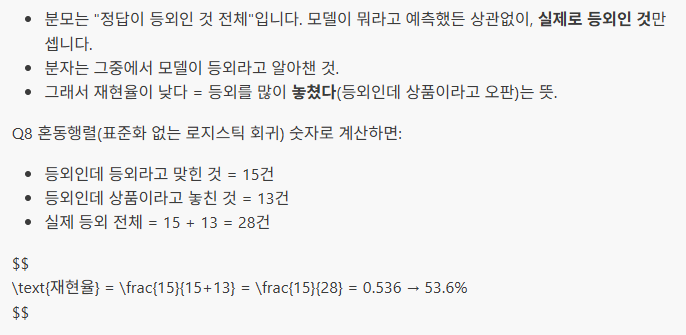

정밀도(Precision)

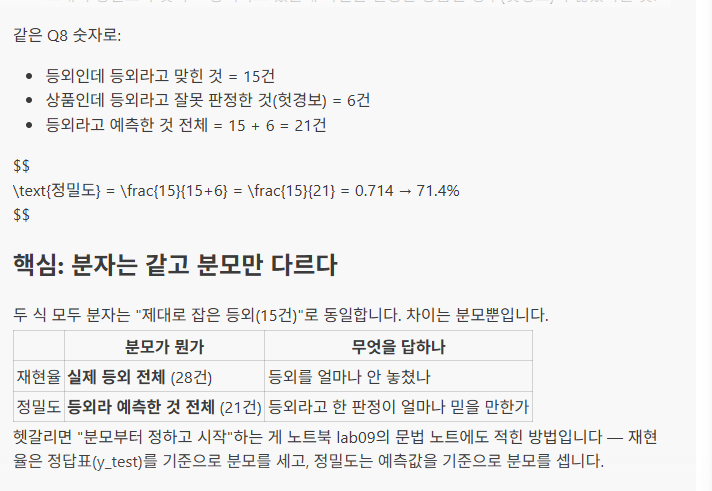

## Q10. 놓친 등외를 더 잡으려면

| 문턱 | 잡은 등외 | 헛경보 | 재현율 | 정밀도 |
|---|---|---|---|---|

### 용어 풀이

| 말 | 뜻 |
|---|---|
| 문턱(threshold) | 등외일 확률이 이 값 이상이면 등외로 판정하는 기준. 기본은 0.5 |
| predict_proba | 모델을 다시 학습시키지 않고, 이미 학습된 모델에 시험용을 넣어 "등외일 확률"만 뽑는다 |

In [13]:
# 모델은 그대로(Q8의 로지스틱 회귀, 표준화 없는 버전) — 문턱만 바꿔서 다시 판정한다
등외확률 = 로지스틱.predict_proba(X_test)[:, 1]

문턱값들 = [0.5, 0.3, 0.2]


def 문턱평가(문턱, 확률):
    예측값 = (확률 >= 문턱).astype(int)
    잡은등외 = int(((예측값 == 1) & (y_test == 1)).sum())
    헛경보 = int(((예측값 == 1) & (y_test == 0)).sum())
    return {
        '문턱': 문턱,
        '잡은 등외': 잡은등외,
        '헛경보': 헛경보,
        '재현율': round(recall_score(y_test, 예측값, zero_division=0), 3),
        '정밀도': round(precision_score(y_test, 예측값, zero_division=0), 3),
    }


문턱비교표 = pd.DataFrame([
    문턱평가(문턱, 등외확률) for 문턱 in 문턱값들
]).set_index('문턱')

문턱비교표

,잡은 등외,헛경보,재현율,정밀도
문턱,,,,
0.5,15,6,0.536,0.714
0.3,18,15,0.643,0.545
0.2,21,22,0.750,0.488


[Q10 결과]

| 문턱 | 잡은 등외 | 헛경보 | 재현율 | 정밀도 |
|---|---|---|---|---|
| 0.5 | [15] | [6] | [0.536] | [0.714] |
| 0.3 | [18] | [15] | [0.643] | [0.545] |
| 0.2 | [21] | [22] | [0.750] | [0.488] |

→ 문턱을 0.5→0.2로 낮출수록 잡는 등외는 15→21건으로 늘어(재현율 53.6%→75.0%), 그 대신 헛경보도 6→22건으로 함께 늘어난다(정밀도 71.4%→48.8%로 하락). 재현율과 정밀도는 서로 밀고 당기는 관계라, 둘 다 동시에 올릴 수는 없고 어느 실수(놓친 등외 vs 헛경보)를 더 감수할지 문턱으로 조절하는 것.

## 마무리 - 어디까지 갔나

[심화 미션] 스마트팜 온실 출하 기록
- 어디까지 풀었나 : [Q8까지]
- 막힌 문항 : Q9번부터 
- 왜 막혔나 : [재현율,정밀도를 조금 알것같으나, 그다음 단계에서 
표를 보고 해석하는 방법이 어려웠다. .특히 f1-score가 뜻하는 의미도 잘 모르겠다. 
              10번은 문턱을 바꾼다는 게 무슨 뜻인지 잘 모르겠다. 더 공부해야겠다. ]
- 오늘 실습과 달랐던 점 : 예시가 전에 배운 실습보다 이해는 쉬웠다.